In [16]:
import pandas as pd

path = '/kaggle/input/d-liu-gn-nhn/user-problem-split-20251006T061232Z-1-001/user-problem-split/part-00000-1ffbdd59-9b66-4d86-9346-5bce8141fa4b-c000.snappy.parquet'
user_problem = pd.read_parquet(path)

print(user_problem.shape)
print(user_problem.head(5))

(6669223, 7)
   attempts  is_correct            log_id  problem_id  score  \
0         1           1  10091134_6899951  Pm_6899951    1.0   
1         1           0  10209699_1676089  Pm_1676089    0.0   
2         3           0  10359753_6565795  Pm_6565795    NaN   
3         1           1  10359421_8434194  Pm_8434194    NaN   
4         3           1  10020095_3919056  Pm_3919056   50.0   

           submit_time     user_id  
0  2020-09-08 10:08:07  U_10091134  
1  2020-07-24 21:02:23  U_10209699  
2  2020-10-26 00:58:00  U_10359753  
3  2020-12-02 19:35:14  U_10359421  
4  2020-07-04 23:33:03  U_10020095  


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [17]:
import json

problem_path = "/kaggle/input/d-liu-gn-nhn/problem.json"

records = []
with open(problem_path, 'r', encoding='utf-8', errors='ignore') as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        try:
            records.append(json.loads(line))
        except Exception as e:
            print(f"Row {i} meets error: {e}")

problem = pd.DataFrame(records)
print(problem.shape)
print(problem.head(5))

Row 855958 meets error: Unterminated string starting at: line 1 column 212 (char 211)
(855958, 12)
   problem_id            title  \
0        1730  第一课 导论与三家分晋--习题   
1        1731  第一课 导论与三家分晋--习题   
2        1732  第一课 导论与三家分晋--习题   
3        1733  第一课 导论与三家分晋--习题   
4        1734  第一课 导论与三家分晋--习题   

                                             content  \
0  1、《资治通鉴》卷1记载：智宣子将以瑶为后，智果曰：“……瑶之贤于人者五，其不逮者一也。美鬓...   
1                                 2、《资治通鉴》是一部____史书。   
2                     3、《资治通鉴》原名____，后由____赐名“资治通鉴”。   
3                                  4、“三家分晋”中“三家”具体指：   
4                     5、智伯联合韩、魏的军队攻打赵氏时，赵襄子选择退守的阵地是：   

                                              option answer  score  type  \
0  {'A': '武艺超群，精通射御之术', 'B': '礼贤下士，虚怀若谷', 'C': '反...  ["B"]    1.0     1   
1  {'A': '纪传体', 'B': '编年体', 'C': '纪事本末体', 'D': '国...  ["B"]    1.0     1   
2  {'A': '《通鉴》；宋神宗', 'B': '《通志》；宋徽宗', 'C': '《通鉴》；...  ["D"]    1.0     1   
3   {'A': '魏赵韩', 'B': '魏韩智', 'C': '赵韩智', 'D': '魏赵智'}  [

In [18]:
import pandas as pd

exercise_problem_path = "/kaggle/input/exercise-problem/exercise-problem.txt"

exercise_problem = pd.read_csv(
    exercise_problem_path,
    sep="\t",
    dtype=str,
    names=["exercise_id", "problem_id"],  
    header=None 
)

print(exercise_problem.shape)
print(exercise_problem.head())

(6252830, 2)
  exercise_id problem_id
0      Ex_143       Pm_1
1      Ex_143       Pm_2
2      Ex_147       Pm_3
3      Ex_147       Pm_4
4      Ex_151       Pm_5


In [19]:
user_course_path = '/kaggle/input/d-liu-gn-nhn/user_course_use_labeling.csv'
user_course = pd.read_csv(user_course_path, encoding='utf-8', on_bad_lines='skip')

user_course.head()

,Unnamed: 0,id_x,course_id,enroll_time,id_y,Video,Assignment,Exam
0,0,U_22,C_682129,2019-10-12 10:28:02,C_682129,0.0,30.0,70.0
1,1,U_24,C_597314,2019-06-12 17:22:07,C_597314,40.0,60.0,0.0
2,2,U_24,C_597208,2019-06-17 15:22:41,C_597208,0.0,100.0,0.0
3,3,U_24,C_682129,2019-10-06 16:23:51,C_682129,0.0,30.0,70.0
4,4,U_24,C_674910,2019-10-08 17:51:04,C_674910,40.0,60.0,0.0


In [20]:
problem["problem_id"] = problem["problem_id"].astype(str)
user_problem["problem_id"] = user_problem["problem_id"].astype(str)

problem["problem_id"] = "Pm_" + problem["problem_id"].astype(str)
merged = pd.merge(user_problem, problem, on="problem_id", how="left")
merged = pd.merge(
    merged,
    user_course,
    how="left",
    left_on="user_id",
    right_on="id_x",
)

print(merged.head())

   attempts  is_correct            log_id  problem_id  score_x  \
0         1           1  10091134_6899951  Pm_6899951      1.0   
1         1           0  10209699_1676089  Pm_1676089      0.0   
2         1           0  10209699_1676089  Pm_1676089      0.0   
3         1           0  10209699_1676089  Pm_1676089      0.0   
4         3           0  10359753_6565795  Pm_6565795      NaN   

           submit_time     user_id                   title  \
0  2020-09-08 10:08:07  U_10091134                     NaN   
1  2020-07-24 21:02:23  U_10209699  第二讲 矩阵与线性方程组--2.4 课后作业   
2  2020-07-24 21:02:23  U_10209699  第二讲 矩阵与线性方程组--2.4 课后作业   
3  2020-07-24 21:02:23  U_10209699  第二讲 矩阵与线性方程组--2.4 课后作业   
4  2020-10-26 00:58:00  U_10359753                     NaN   

                                             content  \
0                                                NaN   
1  将平面上任意向量[mathjaxinline]left(begin{matrix}xyend...   
2  将平面上任意向量[mathjaxinline]left(begin{matrix}xyend...   
3  将平面

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [21]:
merged = merged.drop(columns=["Unnamed: 0"], errors="ignore")
merged = merged.drop(columns=["id_x"], errors="ignore")
merged = merged.drop(columns=["id_y"], errors="ignore")

In [22]:
import ast
import matplotlib.pyplot as plt
import numpy as np

def count_context_ids(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0

    if isinstance(x, (list, np.ndarray)):
        return len(x)
        
    if isinstance(x, str):
        s = x.strip()
        if s in ("", "[]"):
            return 0
        try:
            val = ast.literal_eval(s)
            if isinstance(val, (list, np.ndarray)):
                return len(val)
            # Handle comma-separated strings like "A,B,C"
            return len([i for i in s.replace("[", "").replace("]", "").split(",") if i.strip()])
        except Exception:
            return 0

    return 0

merged["num_context_ids"] = merged["context_id"].apply(count_context_ids)
merged["language_binary"] = merged["language"].map(
        lambda x: 1 if str(x).strip().lower() == "english" else 0)

sort_cols = [c for c in ["user_id", "course_id", "exercise_id", "problem_id"] if c in merged.columns]
if sort_cols:
    merged = merged.sort_values(sort_cols, ignore_index=True)
else:
    print("No sorting columns found in merged_all.")

In [23]:
merged

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,attempts,is_correct,log_id,problem_id,score_x,submit_time,user_id,title,content,option,...,context_id,exercise_id,language,course_id,enroll_time,Video,Assignment,Exam,num_context_ids,language_binary
0,1,0,10000130_4482263,Pm_4482263,-1.0,2020-06-29 18:17:41,U_10000130,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,1,0,10000423_4155670,Pm_4155670,40.0,2020-06-28 13:28:29,U_10000423,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,2,1,10000426_3919049,Pm_3919049,50.0,2020-07-04 15:06:21,U_10000426,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,1,0,10000444_4125691,Pm_4125691,-1.0,2020-06-22 01:18:24,U_10000444,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,1,0,10000444_5567926,Pm_5567926,-1.0,2020-07-19 00:51:02,U_10000444,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11975831,1,1,9998662_3623031,Pm_3623031,50.0,2020-05-18 22:00:52,U_9998662,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
11975832,1,1,9998662_3707324,Pm_3707324,50.0,2020-05-26 21:44:27,U_9998662,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
11975833,1,1,9998668_3707324,Pm_3707324,50.0,2020-05-30 12:13:14,U_9998668,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
11975834,1,1,9998668_3919085,Pm_3919085,50.0,2020-06-18 22:41:06,U_9998668,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [24]:
merged = merged.dropna()
merged

,attempts,is_correct,log_id,problem_id,score_x,submit_time,user_id,title,content,option,...,context_id,exercise_id,language,course_id,enroll_time,Video,Assignment,Exam,num_context_ids,language_binary
348,1,1,1000979_1742172,Pm_1742172,0.8,2020-05-19 14:36:58,U_1000979,随堂测试,安全性关注的是,"{'A': '软件修改的成本', 'B': '软件运行的速度', 'C': '软件的故障',...",...,[6338907],Ex_1431547,Chinese,C_947149,2020-03-03 00:03:14,10.0,55.0,35.0,1,0
349,1,1,1000979_1742182,Pm_1742182,0.8,2020-05-19 14:39:14,U_1000979,随堂测试,易用性关注的是,"{'A': '软件的故障', 'B': '尽可能让软件bug在测试中暴露出来', 'C': ...",...,[1431550],Ex_1431551,Chinese,C_947149,2020-03-03 00:03:14,10.0,55.0,35.0,1,0
350,1,1,1000979_1742191,Pm_1742191,0.8,2020-05-19 14:42:41,U_1000979,随堂测验,哪种图定义了系统功能需求，并不描述功能的具体实现,"{'A': '类图', 'B': '用例图', 'C': '组件图', 'D': '部署图'}",...,[6338975],Ex_1431555,Chinese,C_947149,2020-03-03 00:03:14,10.0,55.0,35.0,1,0
352,1,0,1000982_1742185,Pm_1742185,0.0,2020-06-30 16:05:09,U_1000982,随堂测试,属于提升可测试性的策略的是,"{'A': '用户的授权', 'B': '把接口和实现分离开', 'C': '把用户界面和系...",...,[6338957],Ex_1431553,Chinese,C_947149,2020-06-30 15:54:15,10.0,55.0,35.0,1,0
353,1,0,1000982_1742196,Pm_1742196,0.0,2020-06-30 16:07:33,U_1000982,随堂测验,软件体系结构评估是在软件测试阶段进行的。,"{'true': '', 'false': ''}",...,[6338997],Ex_1431557,Chinese,C_947149,2020-06-30 15:54:15,10.0,55.0,35.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11975802,1,0,999821_1628691,Pm_1628691,0.0,2020-05-14 19:09:20,U_999821,第3讲 利率的决定--作业,名义利率与实际利率往往同向变化，即名义利率上升时，实际利率也会上升。,"{'true': '正确', 'false': '错误'}",...,"[6409611, 6409612, 6409613, 6409614, 6409615, ...",Ex_1367315,Chinese,C_697188,2020-02-10 10:47:38,0.0,0.0,100.0,6,0
11975803,1,0,999821_1628691,Pm_1628691,0.0,2020-05-14 19:09:20,U_999821,第3讲 利率的决定--作业,名义利率与实际利率往往同向变化，即名义利率上升时，实际利率也会上升。,"{'true': '正确', 'false': '错误'}",...,"[6409611, 6409612, 6409613, 6409614, 6409615, ...",Ex_1367315,Chinese,C_697828,2020-02-10 10:56:59,40.0,30.0,30.0,6,0
11975804,1,0,999821_1628691,Pm_1628691,0.0,2020-05-14 19:09:20,U_999821,第3讲 利率的决定--作业,名义利率与实际利率往往同向变化，即名义利率上升时，实际利率也会上升。,"{'true': '正确', 'false': '错误'}",...,"[6409611, 6409612, 6409613, 6409614, 6409615, ...",Ex_1367315,Chinese,C_707081,2020-02-10 11:02:34,30.0,40.0,30.0,6,0
11975805,1,0,999821_1628691,Pm_1628691,0.0,2020-05-14 19:09:20,U_999821,第3讲 利率的决定--作业,名义利率与实际利率往往同向变化，即名义利率上升时，实际利率也会上升。,"{'true': '正确', 'false': '错误'}",...,"[6409611, 6409612, 6409613, 6409614, 6409615, ...",Ex_1367315,Chinese,C_735395,2020-02-01 22:28:25,40.0,60.0,0.0,6,0


In [25]:
print(merged.columns)

Index(['attempts', 'is_correct', 'log_id', 'problem_id', 'score_x',
       'submit_time', 'user_id', 'title', 'content', 'option', 'answer',
       'score_y', 'type', 'typetext', 'location', 'context_id', 'exercise_id',
       'language', 'course_id', 'enroll_time', 'Video', 'Assignment', 'Exam',
       'num_context_ids', 'language_binary'],
      dtype='object')


In [26]:
import polars as pl

# === 1️⃣ Chuyển Pandas → Polars ===
pl_df = pl.from_pandas(merged)

# === 2️⃣ Chuyển đổi cột thời gian nhanh gọn ===
pl_df = pl_df.with_columns(
    pl.col("submit_time").str.strptime(pl.Datetime, format=None).alias("submit_dt")
)

# === 3️⃣ Lấy ngày & giờ ===
pl_df = pl_df.with_columns([
    pl.col("submit_dt").dt.date().alias("submit_date"),
    pl.col("submit_dt").dt.time().alias("submit_clock_time")
])

# === 4️⃣ Xác định các cột nhóm ===
group_cols = [c for c in ["user_id", "course_id", "exercise_id"] if c in pl_df.columns]
if not group_cols:
    raise ValueError("No valid grouping columns found.")

# === 5️⃣ Các phép gộp cần thiết ===
agg_exprs = []
if "is_correct" in pl_df.columns:
    agg_exprs += [
        pl.col("is_correct").sum().alias("is_correct_sum"),
        pl.col("is_correct").count().alias("is_correct_count"),
        pl.col("is_correct").mean().alias("is_correct_mean")
    ]
if "attempts" in pl_df.columns:
    agg_exprs += [
        pl.col("attempts").sum().alias("attempts_sum"),
        pl.col("attempts").mean().alias("attempts_mean")
    ]
# 🟢 score_x = điểm học viên đạt được
if "score_x" in pl_df.columns:
    agg_exprs += [
        pl.col("score_x").sum().alias("score_x_sum"),
        pl.col("score_x").count().alias("score_x_count"),
        pl.col("score_x").mean().alias("score_x_mean")
    ]
# 🟣 score_y = điểm tối đa của problem
if "score_y" in pl_df.columns:
    agg_exprs += [
        pl.col("score_y").sum().alias("score_y_sum"),
        pl.col("score_y").count().alias("score_y_count"),
        pl.col("score_y").mean().alias("score_y_mean")
    ]
if "num_context_ids" in pl_df.columns:
    agg_exprs += [
        pl.col("num_context_ids").sum().alias("num_context_ids_sum"),
        pl.col("num_context_ids").mean().alias("num_context_ids_mean")
    ]
if "language_binary" in pl_df.columns:
    agg_exprs += [
        pl.col("language_binary").sum().alias("language_binary_sum"),
        pl.col("language_binary").mean().alias("language_binary_mean")
    ]
if "submit_dt" in pl_df.columns:
    agg_exprs += [
        pl.col("submit_dt").min().alias("submit_min_dt"),
        pl.col("submit_dt").max().alias("submit_max_dt")
    ]

# === 6️⃣ Groupby song song bằng LazyFrame ===
lazy = pl_df.lazy().group_by(group_cols).agg(agg_exprs)

# === 7️⃣ Tính thời gian chênh lệch giữa lần nộp đầu/cuối ===
lazy = lazy.with_columns(
    (pl.col("submit_max_dt") - pl.col("submit_min_dt"))
    .dt.total_hours()
    .alias("submit_time_diff_hours")
)

# === 8️⃣ Tính tỷ lệ đúng & tỷ lệ điểm ===
lazy = lazy.with_columns([
    # Tỷ lệ đúng: số câu đúng / tổng câu
    (pl.col("is_correct_sum") / pl.col("is_correct_count"))
        .fill_nan(0)
        .fill_null(0)
        .alias("percentage_correct"),

    # Tỷ lệ điểm: tổng điểm đạt được / tổng điểm tối đa
    (pl.col("score_x_sum") / pl.col("score_y_sum"))
        .fill_nan(0)
        .fill_null(0)
        .alias("percentage_score")
])

# === 9️⃣ Thực thi LazyFrame ===
grouped_lists = lazy.collect().to_pandas()

print(grouped_lists[["user_id", "exercise_id", "percentage_correct", "percentage_score"]].head())


      user_id exercise_id  percentage_correct  percentage_score
0  U_29482977  Ex_1368315                 0.0               0.0
1     U_90449  Ex_1262933                 1.0               1.0
2  U_26638392  Ex_1242210                 1.0               1.0
3  U_30611051  Ex_1340141                 1.0               1.0
4  U_14281891  Ex_1258946                 0.0               0.0


In [27]:
exercise_problem

,exercise_id,problem_id
0,Ex_143,Pm_1
1,Ex_143,Pm_2
2,Ex_147,Pm_3
3,Ex_147,Pm_4
4,Ex_151,Pm_5
...,...,...
6252825,Ex_8600262,Pm_8602347
6252826,Ex_8753628,Pm_8602348
6252827,Ex_8753676,Pm_8602349
6252828,Ex_8753787,Pm_8602350


In [28]:
merged.columns

Index(['attempts', 'is_correct', 'log_id', 'problem_id', 'score_x',
       'submit_time', 'user_id', 'title', 'content', 'option', 'answer',
       'score_y', 'type', 'typetext', 'location', 'context_id', 'exercise_id',
       'language', 'course_id', 'enroll_time', 'Video', 'Assignment', 'Exam',
       'num_context_ids', 'language_binary'],
      dtype='object')

In [29]:
grouped_lists.columns

Index(['user_id', 'course_id', 'exercise_id', 'is_correct_sum',
       'is_correct_count', 'is_correct_mean', 'attempts_sum', 'attempts_mean',
       'score_x_sum', 'score_x_count', 'score_x_mean', 'score_y_sum',
       'score_y_count', 'score_y_mean', 'num_context_ids_sum',
       'num_context_ids_mean', 'language_binary_sum', 'language_binary_mean',
       'submit_min_dt', 'submit_max_dt', 'submit_time_diff_hours',
       'percentage_correct', 'percentage_score'],
      dtype='object')

In [30]:
import pandas as pd
import os

# === 1️⃣ Tạo thư mục lưu dữ liệu ===
save_dir = "/kaggle/working"
os.makedirs(save_dir, exist_ok=True)

# === 2️⃣ Hàm tiện ích lưu DataFrame ra Parquet ===
def save_parquet(df, name):
    path = os.path.join(save_dir, f"{name}.parquet")
    df.to_parquet(path, index=False)
    print(f"✅ Saved: {path}  ({len(df):,} rows, {len(df.columns)} cols)")

# === 3️⃣ Lưu từng bảng quan trọng ===
save_parquet(merged, "merged")
save_parquet(grouped_lists, "grouped_lists")
save_parquet(exercise_problem, "exercise_problem")

# (Nếu bạn có thêm user_problem, problem_info,… có thể lưu thêm)
if 'user_problem' in locals():
    save_parquet(user_problem, "user_problem")
if 'problem_info' in locals():
    save_parquet(problem_info, "problem_info")

print("💾 Tất cả các DataFrame đã được lưu thành công.")


✅ Saved: /kaggle/working/merged.parquet  (3,262,624 rows, 25 cols)
✅ Saved: /kaggle/working/grouped_lists.parquet  (2,565,163 rows, 23 cols)
✅ Saved: /kaggle/working/exercise_problem.parquet  (6,252,830 rows, 2 cols)
✅ Saved: /kaggle/working/user_problem.parquet  (6,669,223 rows, 7 cols)
💾 Tất cả các DataFrame đã được lưu thành công.


In [31]:
del merged
del grouped_lists
del exercise_problem
import gc
gc.collect()

0

In [32]:
import polars as pl

lf_merged = pl.scan_parquet(f"{save_dir}/merged.parquet")
lf_grouped = pl.scan_parquet(f"{save_dir}/grouped_lists.parquet")
lf_exercise_problem = pl.scan_parquet(f"{save_dir}/exercise_problem.parquet")

print(lf_merged)


naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

Parquet SCAN [/kaggle/working/merged.parquet]
PROJECT */25 COLUMNS


In [33]:
merge_keys = [c for c in ["user_id", "course_id", "exercise_id"]
              if c in lf_merged.columns and c in lf_grouped.columns]

print("🔑 Merge keys:", merge_keys)

# === 4️⃣ Thực hiện join (streaming mode để tiết kiệm RAM) ===
lf_joined = lf_merged.join(
    lf_grouped,
    on=merge_keys,
    how="left",
    suffix="_agg"
)

pl_merged = lf_joined.collect(streaming=True)

🔑 Merge keys: ['user_id', 'course_id', 'exercise_id']


/tmp/ipykernel_51/3160268729.py:2: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if c in lf_merged.columns and c in lf_grouped.columns]
/tmp/ipykernel_51/3160268729.py:14: DeprecationWarning: The argument `streaming=True` is deprecated and is being replaced by the `engine` argument.
  pl_merged = lf_joined.collect(streaming=True)
/tmp/ipykernel_51/3160268729.py:14: DeprecationWarning: The old streaming engine is being deprecated and will soon be replaced by the new streaming engine. Starting Polars version 1.23.0 and until the new streaming engine is released, the old streaming engine may become less usable. For people who rely on the old streaming engine, it is suggested to pin your version to before 1.23.0.

More information on the new streaming engine: https://github.com/pola-rs/polars/issues/20947
  pl_

In [34]:
del lf_joined
import gc
gc.collect()

0

In [35]:
pl_merged.columns

['attempts',
 'is_correct',
 'log_id',
 'problem_id',
 'score_x',
 'submit_time',
 'user_id',
 'title',
 'content',
 'option',
 'answer',
 'score_y',
 'type',
 'typetext',
 'location',
 'context_id',
 'exercise_id',
 'language',
 'course_id',
 'enroll_time',
 'Video',
 'Assignment',
 'Exam',
 'num_context_ids',
 'language_binary',
 'is_correct_sum',
 'is_correct_count',
 'is_correct_mean',
 'attempts_sum',
 'attempts_mean',
 'score_x_sum',
 'score_x_count',
 'score_x_mean',
 'score_y_sum',
 'score_y_count',
 'score_y_mean',
 'num_context_ids_sum',
 'num_context_ids_mean',
 'language_binary_sum',
 'language_binary_mean',
 'submit_min_dt',
 'submit_max_dt',
 'submit_time_diff_hours',
 'percentage_correct',
 'percentage_score']

In [36]:
import polars as pl
import numpy as np

# 🧮 1️⃣ Tính toán thống kê hoàn thành bài tập (per exercise_id)
aggregated_scores = (
    pl_merged.group_by(["user_id", "course_id", "exercise_id"], maintain_order=True)
    .agg([
        pl.col("problem_id").n_unique().alias("problem_count"),
        pl.col("score_y").sum().alias("problem_sum"),  # hoặc pl.col("score_max").sum()
    ])
)

print("✅ aggregated_scores:")
print(aggregated_scores.head())


pl_merged = pl_merged.join(
    aggregated_scores,
    on=["user_id", "course_id", "exercise_id"],
    how="left"
)

# ✅ 3️⃣ Tạo cột hoàn thành & các tỷ lệ
pl_merged = pl_merged.with_columns([
    (pl.when(pl.col("is_correct") >= 1).then(1).otherwise(0)).alias("is_completed"),
    (
        (pl.col("is_correct").cast(pl.Float64))
        .over("exercise_id")
        .sum() / pl.col("problem_count")
    ).clip(upper_bound=1).alias("percentage_completed"),
])

# Tỷ lệ chính xác & điểm
pl_merged = pl_merged.with_columns([
    pl.col("percentage_completed").alias("percentage_correct_completed"),
    (
        pl.when(pl.col("problem_sum") > 0)
        .then(pl.col("score_x") / pl.col("problem_sum"))
        .otherwise(pl.col("percentage_completed"))
    ).clip(upper_bound=1).alias("percentage_score_completed"),
])

# 🧹 4️⃣ Loại bỏ các cột list nếu có
drop_cols = [
    c for c in ["submit_date_list", "attempts_list", "submit_clock_time_list"]
    if c in pl_merged.columns
]
pl_merged = pl_merged.drop(drop_cols)

pl_merged = pl_merged.with_columns([
    pl.col("submit_time").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False).alias("submit_dt"),
    pl.col("enroll_time").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False),
])
pl_merged = pl_merged.with_columns([
    (pl.col("submit_dt") - pl.col("enroll_time")).dt.total_days().alias("duration_days")
])

pl_merged = pl_merged.with_columns([
    pl.when(pl.col("score_x").is_null() & pl.col("score_y").is_not_null() & (pl.col("is_correct") == 1))
      .then(pl.col("score_y"))
      .when(pl.col("score_x").is_null() & pl.col("score_y").is_not_null() & (pl.col("is_correct") == 0))
      .then(0)
      .when(pl.col("score_x").is_null() & pl.col("score_y").is_null() & (pl.col("is_correct") == 1))
      .then(1)
      .when(pl.col("score_x").is_null() & pl.col("score_y").is_null() & (pl.col("is_correct") == 0))
      .then(0)
      .otherwise(pl.col("score_x"))
      .alias("score_x_filled")
])

# 🏁 8️⃣ Cập nhật score_pm_info theo điểm tối đa
max_scores = (
    pl_merged.group_by("problem_id")
    .agg(pl.col("score_x_filled").max().alias("max_score"))
)
pl_merged = pl_merged.join(max_scores, on="problem_id", how="left")

pl_merged = pl_merged.with_columns([
    pl.when(pl.col("score_y") < pl.col("max_score"))
      .then(pl.col("max_score"))
      .otherwise(pl.col("score_y"))
      .alias("score_pm_info_updated")
]).drop("max_score")

# 💾 9️⃣ Lưu kết quả cuối
output_path = "/kaggle/working/merged_final_with_completion.parquet"
pl_merged.write_parquet(output_path)
print(f"✅ Đã lưu file: {output_path}")
print("🎯 Các cột thống kê mới gồm:",
      [c for c in pl_merged.columns if any(x in c for x in ["percentage", "is_", "duration"])])


✅ aggregated_scores:
shape: (5, 5)
┌───────────┬───────────┬─────────────┬───────────────┬─────────────┐
│ user_id   ┆ course_id ┆ exercise_id ┆ problem_count ┆ problem_sum │
│ ---       ┆ ---       ┆ ---         ┆ ---           ┆ ---         │
│ str       ┆ str       ┆ str         ┆ u32           ┆ f64         │
╞═══════════╪═══════════╪═════════════╪═══════════════╪═════════════╡
│ U_1000979 ┆ C_947149  ┆ Ex_1431547  ┆ 1             ┆ 0.8         │
│ U_1000979 ┆ C_947149  ┆ Ex_1431551  ┆ 1             ┆ 0.8         │
│ U_1000979 ┆ C_947149  ┆ Ex_1431555  ┆ 1             ┆ 0.8         │
│ U_1000982 ┆ C_947149  ┆ Ex_1431553  ┆ 1             ┆ 0.8         │
│ U_1000982 ┆ C_947149  ┆ Ex_1431557  ┆ 2             ┆ 1.6         │
└───────────┴───────────┴─────────────┴───────────────┴─────────────┘
✅ Đã lưu file: /kaggle/working/merged_final_with_completion.parquet
🎯 Các cột thống kê mới gồm: ['is_correct', 'is_correct_sum', 'is_correct_count', 'is_correct_mean', 'percentage_correct', 'perc

In [37]:
pl_merged

attempts,is_correct,log_id,problem_id,score_x,submit_time,user_id,title,content,option,answer,score_y,type,typetext,location,context_id,exercise_id,language,course_id,enroll_time,Video,Assignment,Exam,num_context_ids,language_binary,is_correct_sum,is_correct_count,is_correct_mean,attempts_sum,attempts_mean,score_x_sum,score_x_count,score_x_mean,score_y_sum,score_y_count,score_y_mean,num_context_ids_sum,num_context_ids_mean,language_binary_sum,language_binary_mean,submit_min_dt,submit_max_dt,submit_time_diff_hours,percentage_correct,percentage_score,problem_count,problem_sum,is_completed,percentage_completed,percentage_correct_completed,percentage_score_completed,submit_dt,duration_days,score_x_filled,score_pm_info_updated
i64,i64,str,str,f64,str,str,str,str,struct[19],str,f64,f64,str,str,list[i64],str,str,str,datetime[μs],f64,f64,f64,i64,i64,i64,u32,f64,i64,f64,f64,u32,f64,f64,u32,f64,i64,f64,i64,f64,datetime[μs],datetime[μs],i64,f64,f64,u32,f64,i32,f64,f64,f64,datetime[μs],i64,f64,f64
1,1,"""1000979_1742172""","""Pm_1742172""",0.8,"""2020-05-19 14:36:58""","""U_1000979""","""随堂测试""","""安全性关注的是""","{""软件修改的成本"",""软件运行的速度"",""软件的故障"",""让非法用户无法使用软件"",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null}","""[""D""]""",0.8,1.0,"""单选题""","""3.3.1""",[6338907],"""Ex_1431547""","""Chinese""","""C_947149""",2020-03-03 00:03:14,10.0,55.0,35.0,1,0,1,1,1.0,1,1.0,0.8,1,0.8,0.8,1,0.8,1,1.0,0,0.0,2020-05-19 14:36:58,2020-05-19 14:36:58,0,1.0,1.0,1,0.8,1,1.0,1.0,1.0,2020-05-19 14:36:58,77,0.8,0.8
1,1,"""1000979_1742182""","""Pm_1742182""",0.8,"""2020-05-19 14:39:14""","""U_1000979""","""随堂测试""","""易用性关注的是""","{""软件的故障"",""尽可能让软件bug在测试中暴露出来"",""软件运行的速度"",""终端用户使用软件难度降低"",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null}","""[""D""]""",0.8,1.0,"""单选题""","""3.5.1""",[1431550],"""Ex_1431551""","""Chinese""","""C_947149""",2020-03-03 00:03:14,10.0,55.0,35.0,1,0,1,1,1.0,1,1.0,0.8,1,0.8,0.8,1,0.8,1,1.0,0,0.0,2020-05-19 14:39:14,2020-05-19 14:39:14,0,1.0,1.0,1,0.8,1,1.0,1.0,1.0,2020-05-19 14:39:14,77,0.8,0.8
1,1,"""1000979_1742191""","""Pm_1742191""",0.8,"""2020-05-19 14:42:41""","""U_1000979""","""随堂测验""","""哪种图定义了系统功能需求，并不描述功能的具体实现""","{""类图"",""用例图"",""组件图"",""部署图"",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null}","""[""B""]""",0.8,1.0,"""单选题""","""2.1""",[6338975],"""Ex_1431555""","""Chinese""","""C_947149""",2020-03-03 00:03:14,10.0,55.0,35.0,1,0,1,1,1.0,1,1.0,0.8,1,0.8,0.8,1,0.8,1,1.0,0,0.0,2020-05-19 14:42:41,2020-05-19 14:42:41,0,1.0,1.0,1,0.8,1,1.0,1.0,1.0,2020-05-19 14:42:41,77,0.8,0.8
1,0,"""1000982_1742185""","""Pm_1742185""",0.0,"""2020-06-30 16:05:09""","""U_1000982""","""随堂测试""","""属于提升可测试性的策略的是""","{""用户的授权"",""把接口和实现分离开"",""把用户界面和系统其它部分隔离开"",""多态"",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null}","""[""B""]""",0.8,1.0,"""单选题""","""3.4.1""",[6338957],"""Ex_1431553""","""Chinese""","""C_947149""",2020-06-30 15:54:15,10.0,55.0,35.0,1,0,0,1,0.0,1,1.0,0.0,1,0.0,0.8,1,0.8,1,1.0,0,0.0,2020-06-30 16:05:09,2020-06-30 16:05:09,0,0.0,0.0,1,0.8,0,1.0,1.0,0.0,2020-06-30 16:05:09,0,0.0,0.8
1,0,"""1000982_1742196""","""Pm_1742196""",0.0,"""2020-06-30 16:07:33""","""U_1000982""","""随堂测验""","""软件体系结构评估是在软件测试阶段进行的。""","{null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""",""""}","""[""false""]""",0.8,6.0,"""判断题""","""4.1""",[6338997],"""Ex_1431557""","""Chinese""","""C_947149""",2020-06-30 15:54:15,10.0,55.0,35.0,1,0,0,2,0.0,2,1.0,0.0,2,0.0,1.6,2,0.8,2,1.0,0,0.0,2020-06-30 16:07:33,2020-06-30 16:07:40,0,0.0,0.0,2,1.6,0,1.0,1.0,0.0,2020-06-30 16:07:33,0,0.0,0.8
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1,0,"""999821_1628691""","""Pm_1628691""",0.0,"""2020-05-14 19:09:20""","""U_999821""","""第3讲 利率的决定--作业""","""名义利率与实际利率往往同向变化，即名义利率上升时，实际利率也…","{null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,""错误"",""正确""}","

In [49]:
import polars as pl

# Kiểm tra kiểu dữ liệu hiện tại
print("submit_time dtype:", pl_merged.schema.get("submit_time"))
print("enroll_time dtype:", pl_merged.schema.get("enroll_time"))

# Nếu là Utf8 (string), thì mới chuyển sang datetime
convert_exprs = []
if pl_merged.schema.get("submit_time") == pl.Utf8:
    convert_exprs.append(
        pl.col("submit_time").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False).alias("submit_time_dt")
    )
else:
    convert_exprs.append(pl.col("submit_time").alias("submit_time_dt"))

if pl_merged.schema.get("enroll_time") == pl.Utf8:
    convert_exprs.append(
        pl.col("enroll_time").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False).alias("enroll_time_dt")
    )
else:
    convert_exprs.append(pl.col("enroll_time").alias("enroll_time_dt"))

# === 1️⃣ Tạo cột datetime an toàn ===
pl_merged = pl_merged.with_columns(convert_exprs)

# === 2️⃣ Tính số ngày kể từ khi đăng ký ===
pl_merged = pl_merged.with_columns(
    (pl.col("submit_time_dt") - pl.col("enroll_time_dt"))
    .dt.total_days()
    .alias("days_since_enroll")
)

# === 3️⃣ Chia phase (mỗi phase = 14 ngày, tối đa 4) ===
pl_merged = pl_merged.with_columns(
    ((pl.col("days_since_enroll") // 14) + 1)
    .clip(lower_bound=1, upper_bound=4)
    .alias("phase")
)

# ✅ Xem kết quả mẫu
pl_merged.select(
    ["user_id", "course_id", "enroll_time_dt", "submit_time_dt", "days_since_enroll", "phase"]
).head(10)


submit_time dtype: String
enroll_time dtype: Datetime(time_unit='us', time_zone=None)


user_id,course_id,enroll_time_dt,submit_time_dt,days_since_enroll,phase
str,str,datetime[μs],datetime[μs],i64,i64
"""U_1000979""","""C_947149""",2020-03-03 00:03:14,2020-05-19 14:36:58,77,4
"""U_1000979""","""C_947149""",2020-03-03 00:03:14,2020-05-19 14:39:14,77,4
"""U_1000979""","""C_947149""",2020-03-03 00:03:14,2020-05-19 14:42:41,77,4
"""U_1000982""","""C_947149""",2020-06-30 15:54:15,2020-06-30 16:05:09,0,1
"""U_1000982""","""C_947149""",2020-06-30 15:54:15,2020-06-30 16:07:33,0,1
"""U_1000982""","""C_947149""",2020-06-30 15:54:15,2020-06-30 16:07:40,0,1
"""U_1001176""","""C_947149""",2020-03-02 23:49:33,2020-05-06 00:29:10,64,4
"""U_1001176""","""C_947149""",2020-03-02 23:49:33,2020-05-06 00:32:01,64,4
"""U_1001176""","""C_947149""",2020-03-02 23:49:33,2020-05-08 23:45:41,66,4


In [51]:
phase_features = (
    pl_merged
    .group_by(["user_id", "course_id", "phase"])
    .agg([
        pl.count("problem_id").alias("num_problems"),
        pl.mean("is_correct").alias("phase_accuracy"),
        pl.sum("is_correct").alias("num_correct"),
        pl.mean("score_x").alias("avg_score_x"),
        pl.mean("score_y").alias("avg_score_y"),
        pl.mean("attempts").alias("avg_attempts"),
        pl.mean("percentage_correct").alias("phase_correct_rate"),
        pl.mean("percentage_score").alias("phase_score_rate"),

        # 🔧 sửa ở đây: dùng total_hours thay vì hours
        (pl.col("submit_time_dt").max() - pl.col("submit_time_dt").min())
            .dt.total_hours().alias("active_hours"),

        pl.n_unique("context_id").alias("unique_contexts"),
        pl.mean("language_binary").alias("language_pref"),
    ])
    .sort(["user_id", "course_id", "phase"])
)

print(phase_features.head(10))
print(f"✅ Shape: {phase_features.shape}")


shape: (10, 14)
┌───────────┬───────────┬───────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ user_id   ┆ course_id ┆ phase ┆ num_proble ┆ … ┆ phase_scor ┆ active_hou ┆ unique_co ┆ language_ │
│ ---       ┆ ---       ┆ ---   ┆ ms         ┆   ┆ e_rate     ┆ rs         ┆ ntexts    ┆ pref      │
│ str       ┆ str       ┆ i64   ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│           ┆           ┆       ┆ u32        ┆   ┆ f64        ┆ i64        ┆ u32       ┆ f64       │
╞═══════════╪═══════════╪═══════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ U_1000979 ┆ C_947149  ┆ 4     ┆ 3          ┆ … ┆ 1.0        ┆ 0          ┆ 3         ┆ 0.0       │
│ U_1000982 ┆ C_947149  ┆ 1     ┆ 3          ┆ … ┆ 0.0        ┆ 0          ┆ 2         ┆ 0.0       │
│ U_1001176 ┆ C_947149  ┆ 4     ┆ 3          ┆ … ┆ 0.333333   ┆ 71         ┆ 3         ┆ 0.0       │
│ U_1001875 ┆ C_926175  ┆ 1     ┆ 5          ┆ … ┆ 1.0        ┆ 24         

In [52]:
pl_pivot = phase_features.pivot(
    index=["user_id", "course_id"],
    columns="phase",
    values=["phase_accuracy", "phase_score_rate", "avg_attempts"]
)

# Tạo các feature xu hướng
for i in range(1, 4):
    pl_pivot = pl_pivot.with_columns(
        (pl.col(f"phase_accuracy_{i+1}") - pl.col(f"phase_accuracy_{i}"))
        .alias(f"accuracy_trend_{i}_to_{i+1}")
    )

print(pl_pivot.head(10))


/tmp/ipykernel_51/1616438710.py:1: DeprecationWarning: The argument `columns` for `DataFrame.pivot` is deprecated. It has been renamed to `on`.
  pl_pivot = phase_features.pivot(


shape: (10, 17)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ user_id   ┆ course_id ┆ phase_acc ┆ phase_acc ┆ … ┆ avg_attem ┆ accuracy_ ┆ accuracy_ ┆ accuracy │
│ ---       ┆ ---       ┆ uracy_4   ┆ uracy_1   ┆   ┆ pts_2     ┆ trend_1_t ┆ trend_2_t ┆ _trend_3 │
│ str       ┆ str       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ o_2       ┆ o_3       ┆ _to_4    │
│           ┆           ┆ f64       ┆ f64       ┆   ┆ f64       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ U_1000979 ┆ C_947149  ┆ 1.0       ┆ null      ┆ … ┆ null      ┆ null      ┆ null      ┆ null     │
│ U_1000982 ┆ C_947149  ┆ null      ┆ 0.0       ┆ … ┆ null      ┆ null      ┆ null      ┆ null     │
│ U_1001176 ┆ C_947149  ┆ 0.333333  ┆ null      ┆ … ┆ null      ┆ null     

In [55]:
import polars as pl
from functools import reduce

# === Tạo đặc trưng hành vi tổng quát ===
behavior_summary = (
    pl_pivot
    .with_columns([
        # 🟢 Số phase mà user có hoạt động (có phase_accuracy khác null)
        reduce(
            lambda a, b: a + b,
            [
                pl.when(pl.col(f"phase_accuracy_{i}").is_not_null()).then(1).otherwise(0)
                for i in range(1, 5)
            ]
        ).alias("num_active_phases"),

        # 🔴 Số phase bị bỏ trống (không hoạt động)
        reduce(
            lambda a, b: a + b,
            [
                pl.when(pl.col(f"phase_accuracy_{i}").is_null()).then(1).otherwise(0)
                for i in range(1, 5)
            ]
        ).alias("num_inactive_phases"),

        # 🟣 Trung bình accuracy trong các phase có hoạt động
        (
            reduce(
                lambda a, b: a + b,
                [pl.col(f"phase_accuracy_{i}").fill_null(0) for i in range(1, 5)]
            ) / 4
        ).alias("avg_accuracy_overall"),

        # 🟡 Độ lệch giữa phase đầu và cuối (đo sự tiến bộ)
        (pl.col("phase_accuracy_4") - pl.col("phase_accuracy_1")).alias("progress_score"),
    ])
)


In [58]:
# === Phân loại hành vi học tập (đã sửa đúng) ===
behavior_summary = behavior_summary.with_columns([
    (
        pl.when(pl.col("num_active_phases") == 4)
          .then(pl.lit("Consistent Learner"))     # bọc trong pl.lit()
        .when(pl.col("num_active_phases") == 1)
          .then(pl.lit("Early Dropout"))
        .when(pl.col("progress_score") > 0.2)
          .then(pl.lit("Improving Learner"))
        .when(pl.col("progress_score") < -0.2)
          .then(pl.lit("Declining Learner"))
        .otherwise(pl.lit("Irregular Learner"))
        .alias("behavior_type")
    )
])


In [59]:
behavior_stats = (
    behavior_summary
    .group_by("behavior_type")
    .agg([
        pl.count().alias("num_users"),
        pl.mean("avg_accuracy_overall").alias("mean_accuracy"),
        pl.mean("progress_score").alias("mean_progress"),
        pl.mean("num_active_phases").alias("mean_active_phases")
    ])
    .sort("num_users", descending=True)
)

print("=== Hành vi học tập tổng quan ===")
print(behavior_stats)


=== Hành vi học tập tổng quan ===
shape: (5, 5)
┌────────────────────┬───────────┬───────────────┬───────────────┬────────────────────┐
│ behavior_type      ┆ num_users ┆ mean_accuracy ┆ mean_progress ┆ mean_active_phases │
│ ---                ┆ ---       ┆ ---           ┆ ---           ┆ ---                │
│ str                ┆ u32       ┆ f64           ┆ f64           ┆ f64                │
╞════════════════════╪═══════════╪═══════════════╪═══════════════╪════════════════════╡
│ Early Dropout      ┆ 517952    ┆ 0.186966      ┆ 0.0           ┆ 1.0                │
│ Irregular Learner  ┆ 42364     ┆ 0.40666       ┆ 0.001136      ┆ 2.19035            │
│ Consistent Learner ┆ 2185      ┆ 0.736367      ┆ 0.022622      ┆ 4.0                │
│ Declining Learner  ┆ 1834      ┆ 0.372836      ┆ -0.5754       ┆ 2.449836           │
│ Improving Learner  ┆ 1556      ┆ 0.388999      ┆ 0.549001      ┆ 2.438303           │
└────────────────────┴───────────┴───────────────┴───────────────┴──────

/tmp/ipykernel_51/1752453051.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias("num_users"),


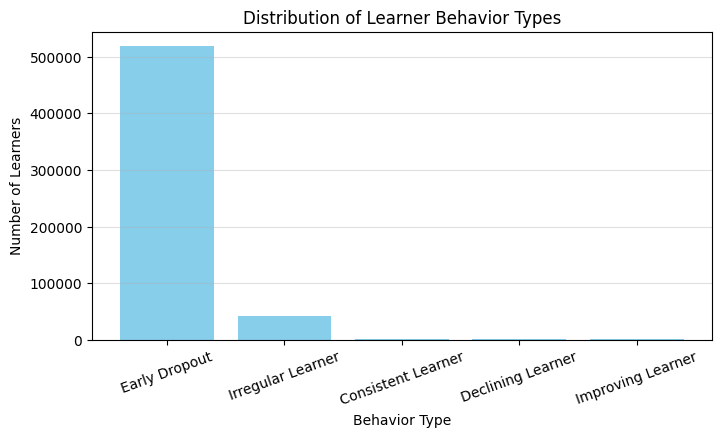

In [60]:
import matplotlib.pyplot as plt

df_plot = behavior_stats.to_pandas()

plt.figure(figsize=(8,4))
plt.bar(df_plot["behavior_type"], df_plot["num_users"], color='skyblue')
plt.title("Distribution of Learner Behavior Types")
plt.xlabel("Behavior Type")
plt.ylabel("Number of Learners")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.4)
plt.show()


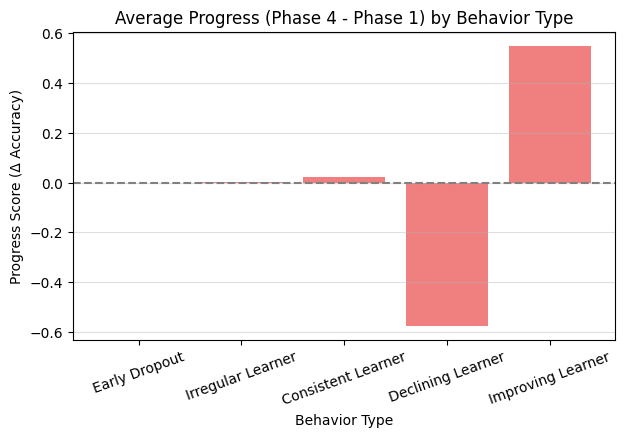

In [61]:
plt.figure(figsize=(7,4))
plt.bar(df_plot["behavior_type"], df_plot["mean_progress"], color='lightcoral')
plt.title("Average Progress (Phase 4 - Phase 1) by Behavior Type")
plt.xlabel("Behavior Type")
plt.ylabel("Progress Score (Δ Accuracy)")
plt.axhline(0, color='gray', linestyle='--')
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.4)
plt.show()


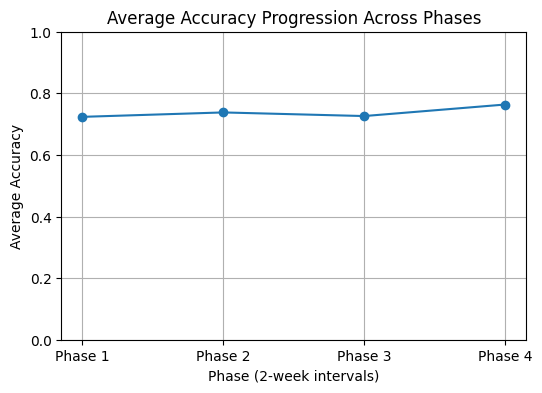

In [62]:
phase_means = {
    f"Phase {i}": pl_pivot.select(pl.mean(f"phase_accuracy_{i}")).item()
    for i in range(1, 5)
}

plt.figure(figsize=(6,4))
plt.plot(list(phase_means.keys()), list(phase_means.values()), marker='o')
plt.title("Average Accuracy Progression Across Phases")
plt.xlabel("Phase (2-week intervals)")
plt.ylabel("Average Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


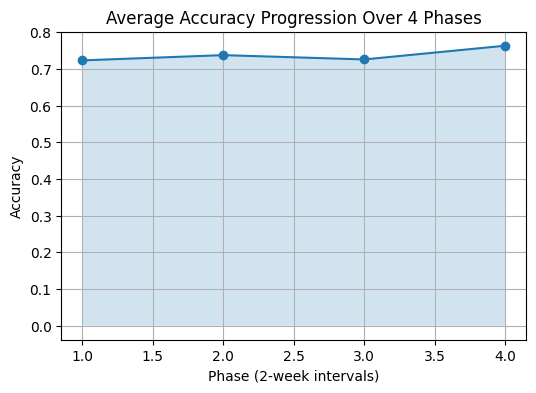

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = behavior_summary.to_pandas()

phase_cols = [f"phase_accuracy_{i}" for i in range(1, 5)]
phase_means = df[phase_cols].mean()

plt.figure(figsize=(6,4))
plt.plot(range(1,5), phase_means, marker='o')
plt.fill_between(range(1,5), phase_means, alpha=0.2)
plt.title("Average Accuracy Progression Over 4 Phases")
plt.xlabel("Phase (2-week intervals)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


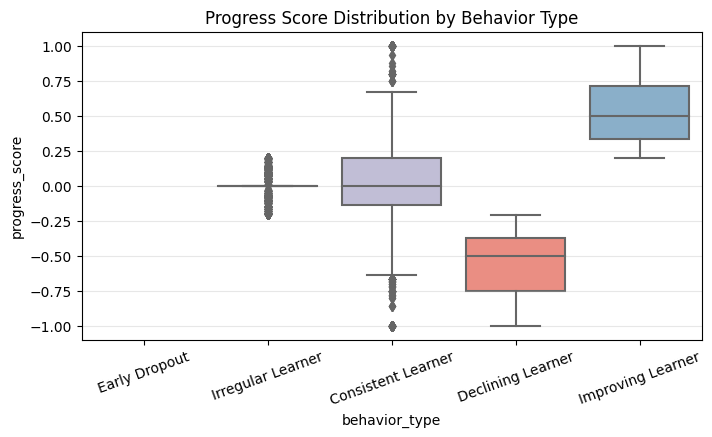

In [64]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="behavior_type", y="progress_score", palette="Set3")
plt.title("Progress Score Distribution by Behavior Type")
plt.xticks(rotation=20)
plt.grid(True, axis="y", alpha=0.3)
plt.show()


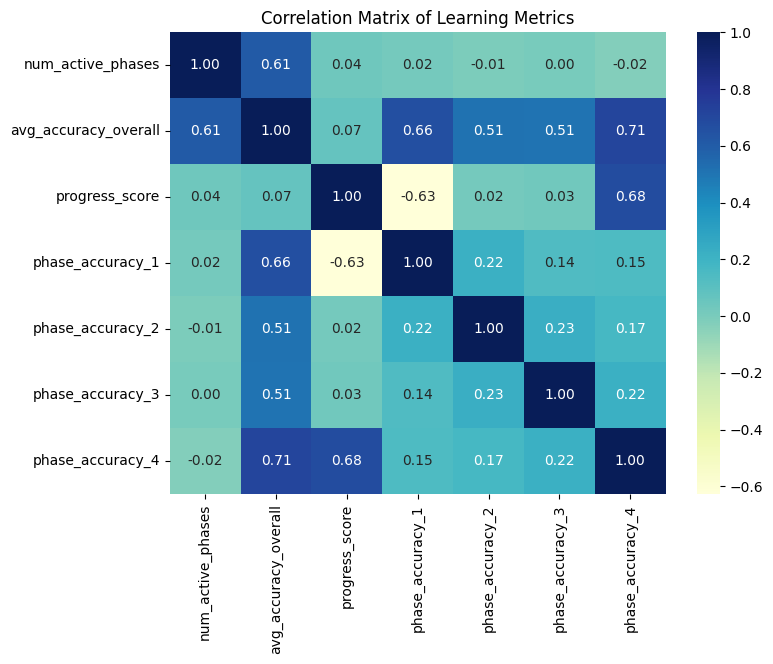

In [65]:
corr = df[["num_active_phases", "avg_accuracy_overall", "progress_score"] + phase_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Correlation Matrix of Learning Metrics")
plt.show()


/usr/local/lib/python3.11/dist-packages/matplotlib/projections/polar.py:76: RuntimeWarning: invalid value encountered in greater_equal
  r = np.where(r >= 0, r, np.nan)
/usr/local/lib/python3.11/dist-packages/matplotlib/projections/polar.py:77: RuntimeWarning: invalid value encountered in cos
  return np.column_stack([r * np.cos(theta), r * np.sin(theta)])
/usr/local/lib/python3.11/dist-packages/matplotlib/projections/polar.py:77: RuntimeWarning: invalid value encountered in sin
  return np.column_stack([r * np.cos(theta), r * np.sin(theta)])


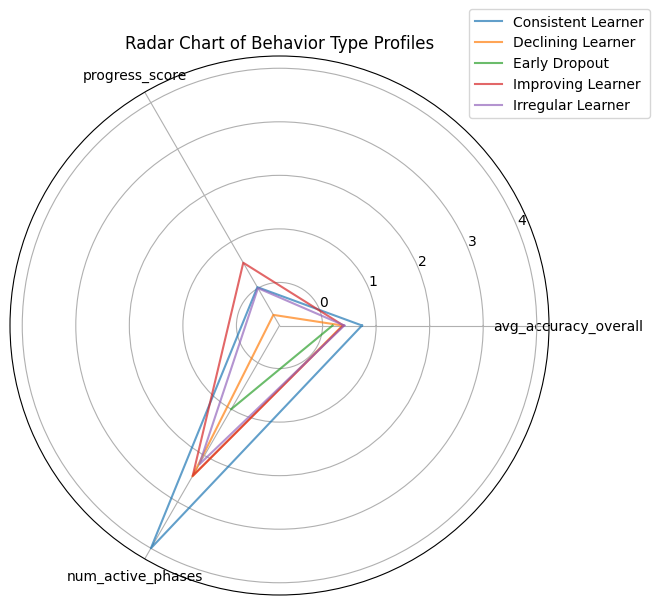

In [66]:
import numpy as np

metrics = ["avg_accuracy_overall", "progress_score", "num_active_phases"]
group_means = df.groupby("behavior_type")[metrics].mean()

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
for i, (group, row) in enumerate(group_means.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    plt.polar(angles, values, label=group, alpha=0.7)

plt.xticks(angles[:-1], metrics)
plt.title("Radar Chart of Behavior Type Profiles")
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.show()


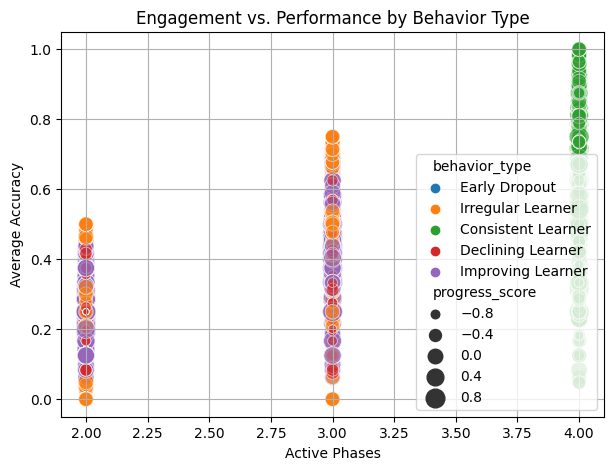

In [67]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="num_active_phases", y="avg_accuracy_overall",
                hue="behavior_type", size="progress_score", sizes=(20,200), alpha=0.6)
plt.title("Engagement vs. Performance by Behavior Type")
plt.xlabel("Active Phases")
plt.ylabel("Average Accuracy")
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



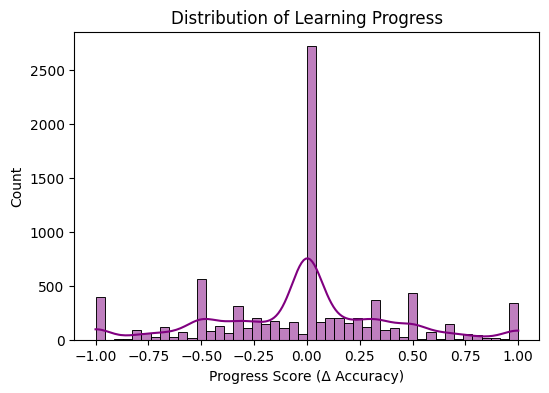

In [69]:
plt.figure(figsize=(6,4))
sns.histplot(df["progress_score"], kde=True, color="purple")
plt.title("Distribution of Learning Progress")
plt.xlabel("Progress Score (Δ Accuracy)")
plt.show()


In [70]:
save_dir = "/kaggle/working"

# === 1️⃣ Các file chính để phân tích ===
pl_merged.write_parquet(f"{save_dir}/merged_final_with_completion.parquet")
behavior_summary.write_parquet(f"{save_dir}/behavior_summary.parquet")
behavior_stats.write_parquet(f"{save_dir}/behavior_stats.parquet")

# Nếu có bảng phase pivot
if 'pl_pivot' in locals():
    pl_pivot.write_parquet(f"{save_dir}/pl_pivot.parquet")

# === 2️⃣ (Tùy chọn) Xuất CSV cho Power BI / Excel ===
behavior_summary.write_csv(f"{save_dir}/behavior_summary.csv")
behavior_stats.write_csv(f"{save_dir}/behavior_stats.csv")

print("✅ Đã lưu tất cả các file quan trọng:")
print("📂 merged_final_with_completion.parquet")
print("📂 behavior_summary.parquet / .csv")
print("📂 behavior_stats.parquet / .csv")
print("📂 pl_pivot.parquet (nếu có)")


✅ Đã lưu tất cả các file quan trọng:
📂 merged_final_with_completion.parquet
📂 behavior_summary.parquet / .csv
📂 behavior_stats.parquet / .csv
📂 pl_pivot.parquet (nếu có)
